In [1]:
from scipy.optimize import minimize
import numpy as np

In [4]:
# 主題：購買蘋果、香蕉限制金額下效用最大化
# 程式碼示範：數使用scipy.optimize.minimize
# 1. 定義目標函數 (Scipy 預設是「最小化」，所以最大化問題要加負號)
def f(x):
    return -x[0]*x[1]
# 2. 定義約束條件
# Scipy 的 'ineq' 代表 g(x) >= 0，所以我們要寫成 100 - 10x - 5y >= 0
def g(x):
    return 100 - 10*x[0] - 5*x[1]
con1 = {'type': 'ineq', 'fun': g}
cons=[con1]

# 3. 定義變數的邊界 (x, y 必須大於 0)
bnds = ((0.001, None), (0.001, None))
# 4. 給予初始猜測值
x = np.array([0,0])
# 5. 執行優化
res=minimize(fun=f,x0=x,method='SLSQP',bounds=bnds,constraints=cons)
# 6. 輸出結果
print(f"最佳蘋果購買數 x: {res.x[0]:.2f}")
print(f"最佳香蕉購買數 y: {res.x[1]:.2f}")
print(f"最大效益: {-res.fun:.2f}")
print(f"拉格朗日乘數:{float(res['multipliers'][0]):.2f}")

最佳蘋果購買數 x: 5.00
最佳香蕉購買數 y: 10.00
最大效益: 50.00
拉格朗日乘數:1.00


In [6]:
from sympy import symbols, diff
from sympy.solvers import solve
# 自訂minimize 函式
class minimizer:
    def __init__(self,constraint):
        self.res_=None
        self.constraint_=constraint
    # 1. 定義目標函數 (預設是「最小化」，所以最大化問題要加負號)
    def f(self,x):
        return -x[0]*x[1]
    # 2. 定義限制條件
    def g(self,x):
        return (10*x[0] + 5*x[1])-self.constraint_
    # 3. 執行優化
    def optimize(self):
        x, y, lambda0 = symbols('x y lambda0', real=True)
        self.x_=x
        self.y_=y
        self.lambda0_=lambda0
        grad=[]
        gradF = [diff(self.f([x,y]), x), diff(self.f([x, y]), y), self.g([x, y])]
        gradG = [diff(self.g([x,y]), x), diff(self.g([x, y]), y)]
        for i in range(0, len(gradF)):
            if(i != len(gradF) - 1):
                grad.append(gradF[i] + lambda0 * gradG[i])
            else:
                grad.append(gradF[i])
        self.res_ = solve(grad, x, y, lambda0)
        return self
    # 4. 顯示結果
    def show_result(self):
        x_star=self.res_[self.x_]
        y_star=self.res_[self.y_]
        print(f"最佳蘋果購買數 x: {self.res_[self.x_]:.2f}")
        print(f"最佳香蕉購買數 y: {self.res_[self.y_]:.2f}")
        print(f"最大效益: {-self.f([x_star,y_star]):.2f}")
        print(f"拉格朗日乘數:{self.res_[self.lambda0_]:.2f}")

# 進行優化
mm=minimizer(constraint=100)
sol=mm.optimize()
# 輸出結果
sol.show_result()

最佳蘋果購買數 x: 5.00
最佳香蕉購買數 y: 10.00
最大效益: 50.00
拉格朗日乘數:1.00


In [90]:
# 成本最小化範例
def f(x, h):
    cost = 20*x**2+40*x*h
    return cost

def g(x, h,surf=0):
    return x**2*h

C:\Users\styeh\AppData\Local\Temp\ipykernel_6712\324777222.py:24: RuntimeWarning: divide by zero encountered in divide
  ax.plot_surface(x1,16/(x1**2),f(x1,16/(x1**2)), rstride=5, cstride=5,
C:\Users\styeh\AppData\Local\Temp\ipykernel_6712\199834595.py:3: RuntimeWarning: invalid value encountered in multiply
  cost = 20*x**2+40*x*h
C:\Users\styeh\AppData\Local\Temp\ipykernel_6712\324777222.py:26: RuntimeWarning: divide by zero encountered in divide
  ax.plot_surface(x1,26/(x1**2),f(x1,26/(x1**2)), rstride=5, cstride=5,
C:\Users\styeh\AppData\Local\Temp\ipykernel_6712\324777222.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


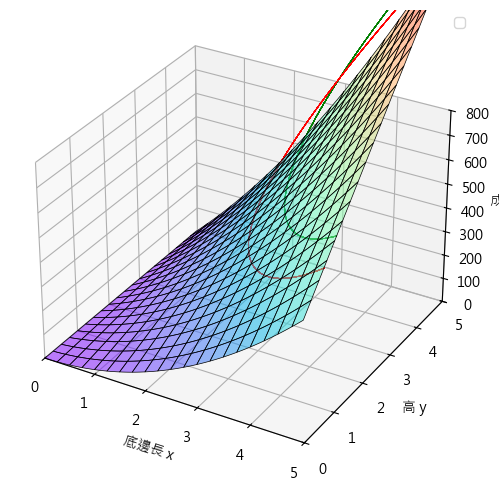

In [134]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
fig = plt.figure(figsize=(10,6),dpi=100)
ax = fig.add_subplot(111, projection='3d')
# ax=plt.subplot(projection='3d')
x = np.linspace(0,5,50)
h = np.linspace(0,5,50)
x1, h1 = np.meshgrid(np.arange(0, 5, 0.05),np.arange(0, 5, 0.05))
v = f(x1,h1)
ax.plot_surface(x1, h1, v, rstride=5, cstride=5, 
                cmap='rainbow', edgecolor='black', linewidth=0.5,alpha=0.5) # Use ax.plot() for lines
# ax.plot(x1.ravel(), h1.ravel(), v, color='b',label='3D Curve') # Use ax.plot() for lines
ax.set_xlabel('底邊長 x')
ax.set_ylabel('高 y')
ax.set_zlabel('成本')
ax.set_xlim(0,5)
ax.set_ylim(0,5)
ax.set_zlim(0,800)

# ax.plot(x1,16/(x1**2),f(x1,16/(x1**2)),color='r')
ax.plot_surface(x1,16/(x1**2),f(x1,16/(x1**2)), rstride=5, cstride=5, 
                cmap='rainbow', edgecolor='red', linewidth=0.5,alpha=0.5)
ax.plot_surface(x1,26/(x1**2),f(x1,26/(x1**2)), rstride=5, cstride=5, 
                cmap='rainbow', edgecolor='green', linewidth=0.5,alpha=0.5)
# ax.plot_surface(x1, h1, Z.reshape(100,100), color='r') # Use ax.plot() for lines
# plt.title('3D Line Plot')
ax.legend()
plt.show()

In [33]:
# 3. 定義變數的邊界 (x, y 必須大於 0)
bnds = ((0.001, None), (0.001, None))
# 4. 給予初始猜測值
x0 = np.array([0,0])
# 5. 執行優化
res=minimize(fun=f,x0=x0,method='SLSQP',bounds=bnds,constraints=cons)
# 6. 輸出結果
print(f"最佳勞動力投入 x: {res.x[0]:.2f}")
print(f"最佳機器投入 y: {res.x[1]:.2f}")
print(f"最大產出量: {-res.fun:.2f}")
print(f"拉格朗日乘數:{float(res['multipliers'][0]):.2f}")

最佳勞動力投入 x: 25.25
最佳機器投入 y: 10.10
最大產出量: 159.70
拉格朗日乘數:1.58


In [36]:
from sympy import symbols, diff
from sympy.solvers import solve

In [50]:
# 自訂minimize 函式
def minimizer(obj_func,const_func,const_value):
    grad=[]
    res = solve(grad, x, y, z, lambda0)
    print(res)

In [60]:
# 1. 定義目標函數 (預設是「最小化」，所以最大化問題要加負號)
def f(x):
    return -10*x[0]**0.5*x[1]**0.5
# 2. 定義限制條件
def g(x):
    return 2*x[0] + 5*x[1] -100
x, y, lambda0 = symbols('x y lambda0', real=True)
grad=[]
gradF = [diff(f([x,y]), x), diff(f([x, y]),  y), g([x, y])]
gradG = [diff(g([x,y]), x), diff(g([x, y]),  y)]
for i in range(0, len(gradF)):
    if(i != len(gradF) - 1):
        grad.append(gradF[i] + lambda0 * gradG[i])
    else:
        grad.append(gradF[i])
print(grad)        
res = solve(grad, x, y, lambda0)
# sol=res[0]
print(res)
# print(f(res))

[2*lambda0 - 5.0*y**0.5/x**0.5, 5*lambda0 - 5.0*x**0.5/y**0.5, 2*x + 5*y - 100]
[(25.0000000000000, 10.0000000000000, 1.58113883008419)]


In [45]:
def lagrange_maximize_3d(obj_func, const_func, const_value):
    """Implementation of Lagrange Multipliers for maximizing
       functions subject to constraints.
       
       Here, I demonstrate how this method can be used to maximize functions with 3 variables
       subject to one constraint function in the same variables"""
    
    x, y, z, lambda0 = symbols('x y z lambda0', real=True)
    gradF = [diff(obj_func(x,y,z), x), diff(obj_func(x, y, z), y), diff(obj_func(x, y, z), z), const_func(x, y, z)]
    gradG = [diff(const_func(x,y,z), x), diff(const_func(x, y, z), y), diff(const_func(x, y, z), z), const_value]
    grad = []

    for i in range(0, len(gradF)):
        print(i)
        if(i != len(gradF) - 1):
            grad.append(gradF[i] - lambda0 * gradG[i])
        
        else:
            grad.append(gradF[i] - float(gradG[i]))
    print(grad)
    sol = solve(grad, x, y, z, lambda0)
    print(sol)
    values = []
    for solution in sol:
        x0 = solution[0]
        y0 = solution[1]
        z0 = solution[2]

        values.append(obj_func(x0, y0, z0))
        
    sol_index = list.index(values, max(values))
    final_solution = sol[sol_index]

    print("Optimal values for maximizing the objective function when the constraint function equals " + str(const_value) + " : ")
    #print("")
    print("x : " + str(final_solution[0]))
    print("y : " + str(final_solution[1]))
    print("z : " + str(final_solution[2]))
    #print("")
    print("Maximum value of the objective function : " + str(obj_func(x0, y0, z0)))

In [46]:
surf = input("Enter value of constraint function : ")

# Example constraint function : g(x, y, z) = 2*(x*y + y*z + z*x). Surface area of a cuboidal box

def g(x, y, z):
    surf = 2*(x*y + y*z + z*x)
    return surf

# Example objective function : f(x, y, z) = x*y*z. Volume of a cuboidal box

def f(x, y, z):
    vol = x*y*z
    return vol

In [47]:
lagrange_maximize_3d(obj_func=f, const_func=g, const_value=surf)

0
1
2
3
[-lambda0*(2*y + 2*z) + y*z, -lambda0*(2*x + 2*z) + x*z, -lambda0*(2*x + 2*y) + x*y, 2*x*y + 2*x*z + 2*y*z - 24.0]
[(-2.00000000000000, -2.00000000000000, -2.00000000000000, -0.500000000000000), (2.00000000000000, 2.00000000000000, 2.00000000000000, 0.500000000000000)]
Optimal values for maximizing the objective function when the constraint function equals 24 : 
x : 2.00000000000000
y : 2.00000000000000
z : 2.00000000000000
Maximum value of the objective function : 8.00000000000000


In [80]:
def lagrange_minimize_cost(obj_func, const_func, const_value):
    """Implementation of Lagrange Multipliers for maximizing
       functions subject to constraints.
       
       Here, I demonstrate how this method can be used to maximize functions with 3 variables
       subject to one constraint function in the same variables"""
    
    x, h, lambda0 = symbols('x h lambda0', real=True)
    # gradF = [diff(obj_func(x,h), x), diff(obj_func(x,h), h), const_func(x, h,const_value)]
    gradL = [diff(obj_func(x,h), x), diff(obj_func(x,h), h), const_func(x, h,const_value)]
    # gradG = [diff(const_func(x,h,const_value), x), diff(const_func(x, h,const_value), h), const_value]
    grad = []

    # for i in range(0, len(gradF)):        
    #     if(i != len(gradF) - 1):
    #         grad.append(gradF[i] + lambda0 * gradG[i])
        
    #     else:
    #         grad.append(gradF[i] + float(gradG[i]))
    # print(grad,gradG[2],gradF[2])
    grad.append(gradL)
    # symbolic_expression = lambda0*(16-x**2*h) 
    # grad.append([symbolic_expression])
    print(grad,gradL)
    sol = solve(grad, x, h, lambda0)
    # lambda_0=sol[2]
    print('lamba_0:',sol)
    values = []
    for solution in sol:
        x0 = solution[0]
        h0 = solution[1]

        values.append(obj_func(x0, h0))
        
    sol_index = list.index(values, max(values))
    final_solution = sol[sol_index]

    print("Optimal values for minimizing the objective function when the constraint function equals " + str(const_value) + " : ")
    #print("")
    print("x : " + str(final_solution[0]))
    print("h : " + str(final_solution[1]))
    #print("")
    print("Minimum value of the objective function : " + str(obj_func(x0, h0)))

In [81]:
def f(x, h):
    cost = 20*x**2+40*x*h
    return cost

def g(x, h,surf):
    return surf-x**2*h
const=16
lagrange_minimize_cost(obj_func=f, const_func=g, const_value=const)


[[40*h + 40*x, 40*x, -h*x**2 + 16]] [40*h + 40*x, 40*x, -h*x**2 + 16]


AttributeError: 'list' object has no attribute 'is_Relational'